In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('C:\\Users\\kadit\\ML-Journey\\datasets\\Social_Network_Ads.csv')

In [ ]:
df.iloc[:, 2:]

In [7]:
df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
75,15651983,Male,34,112000,1
211,15735878,Male,52,150000,1
223,15593715,Male,60,102000,1
345,15716781,Female,41,63000,0
245,15722061,Female,51,146000,1


In [8]:
# Before starting with feature scaling, "Train Test Split" is a must for both "standardization" and "normalization". This is because we want to avoid data leakage. If we perform feature scaling before splitting the data, the scaling parameters (like mean and standard deviation for standardization) will be calculated using the entire dataset, including the test set. This can lead to data leakage, where information from the test set is inadvertently used during training, resulting in overly optimistic performance estimates. By splitting the data first, we ensure that the scaling parameters are calculated only on the training set, and then applied to both the training and test sets, thus maintaining the integrity of our model evaluation.

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((280, 4), (120, 4), (280,), (120,))

In [ ]:
# Converting string values to numeric values for data preprocessing.:

X_train['Gender'] = X_train['Gender'].map({'Male': 1, 'Female': 0})
X_test['Gender'] = X_test['Gender'].map({'Male': 1, 'Female': 0})

In [11]:
# Standard Scaler:

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
scaler.mean_

array([1.56917817e+07, 5.03571429e-01, 3.78642857e+01, 6.98071429e+04])

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# as the "X_train_scaled" and "X_test_scaled" are in the form of numpy arrays, we need to convert them back to pandas DataFrame to make it easier for further analysis and modeling. By converting them back to DataFrames, we can retain the column names and easily manipulate the data using pandas functionalities. This also allows us to maintain consistency with the original data structure, making it easier to interpret and work with the scaled features in subsequent steps of our machine learning pipeline.

In [14]:
np.round(X_train.describe(), 1)

,User ID,Gender,Age,EstimatedSalary
count,280.0,280.0,280.0,280.0
mean,15691781.7,0.5,37.9,69807.1
std,70759.6,0.5,10.2,34641.2
min,15569641.0,0.0,18.0,15000.0
25%,15628197.2,0.0,30.0,43000.0
50%,15694424.0,1.0,37.0,70500.0
75%,15751110.8,1.0,46.0,88000.0
max,15814816.0,1.0,60.0,150000.0


In [15]:
np.round(X_train_scaled.describe(), 1)

,User ID,Gender,Age,EstimatedSalary
count,280.0,280.0,280.0,280.0
mean,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0
min,-1.7,-1.0,-1.9,-1.6
25%,-0.9,-1.0,-0.8,-0.8
50%,0.0,1.0,-0.1,0.0
75%,0.8,1.0,0.8,0.5
max,1.7,1.0,2.2,2.3


Text(0.5, 1.0, 'After Scaling')

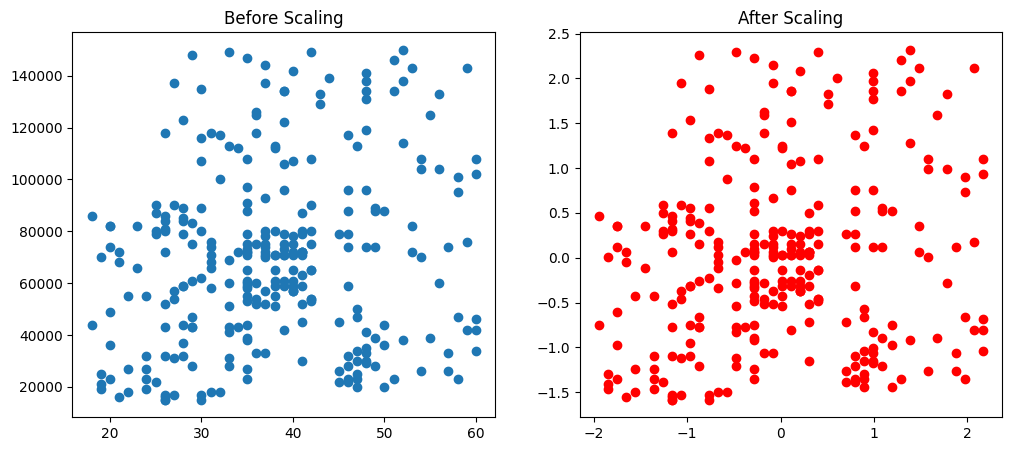

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title('After Scaling')

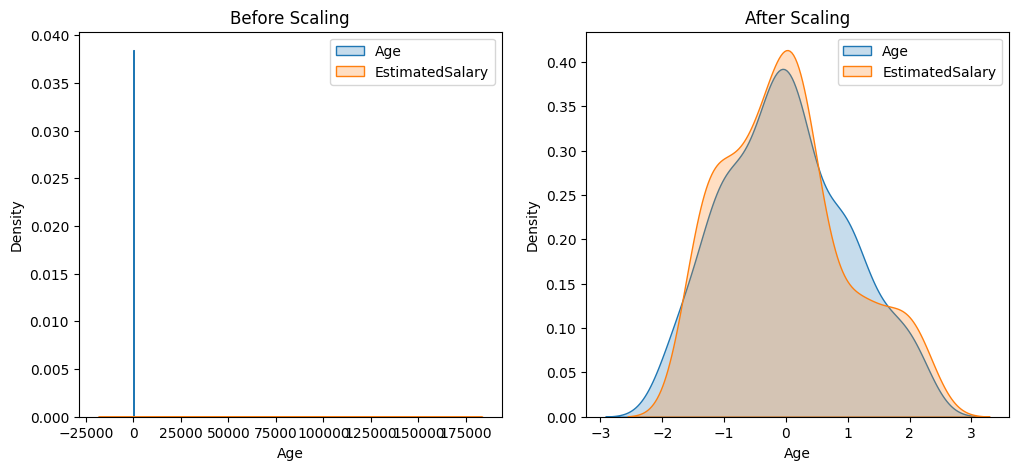

In [21]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1, label='Age', fill=True)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, label='EstimatedSalary', fill=True)
legend = ax1.legend(loc='upper right')

ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2, label='Age', fill=True)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, label='EstimatedSalary', fill=True)
legend = ax2.legend(loc='upper right')

plt.show()

In [ ]:
# Why scaling is important?

from sklearn.linear_model import LogisticRegression

# Also, before performing logistic regression, we need to scale the features

In [23]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [24]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
print("Accuracy before scaling:", accuracy_score(y_test, y_pred))
print("Accuracy after scaling:", accuracy_score(y_test, y_pred_scaled))

Accuracy before scaling: 0.8666666666666667
Accuracy after scaling: 0.8833333333333333


# Impact of Outliers on Standardization:

We need to handle the outliers explicitly before performing standardization. This is because standardization is sensitive to outliers, as it uses the mean and standard deviation of the data to scale the features. If there are outliers present in the data, they can significantly affect the mean and standard deviation, leading to skewed scaling of the features. This can result in distorted feature distributions and may negatively impact the performance of machine learning models. Therefore, it is important to identify and handle outliers appropriately (e.g., by removing them or using robust scaling techniques) before applying standardization to ensure that the features are scaled effectively and the model can learn from the data without being influenced by extreme values.

# When to use standardization?

Whenever we have to deal with any of the below algorithms, without any doubt apply standardization:

1. K-Means
2. KNN
3. PCA
4. Artificial Neural Netwoks
5. Gradient Descent